# Step 0: Sensor Data Exploration
## IMU-based Indoor Localization Thesis - Testdrive

This notebook explores sensor data recorded with [Sensor Logger](https://www.tszheichoi.com/sensorlogger) from an Android phone + smartwatch.

**Two recordings:**
- `default/` — Recorded using Android OS built-in sensor fusion (100Hz)
- `sensorzoo/` — Recorded using Sensor Zoo algorithms (Madgwick orientation, Adaptive Threshold step counter, Tilt-Compensated compass) (100Hz)

**Activity:** Walking for ~25 seconds, then sitting for ~10 seconds. Annotations mark transitions.

**Goals:**
1. Understand what each sensor looks like during walking vs. sitting
2. Compare default vs. Sensor Zoo outputs
3. Check data quality and format for MobilePoser compatibility
4. Verify Wi-Fi scans all nearby APs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Ready!')

Ready!


## 1. Load Data

Update the paths below to point to your two recording folders.

In [2]:
# === UPDATE THESE PATHS ===
DEFAULT_DIR = Path('data/walking-sitting/default/')    # folder with default recording CSVs
ZOO_DIR = Path('data/walking-sitting/sensorzoo/')      # folder with sensor zoo recording CSVs

def load_csv(folder, name):
    """Load a CSV file from a recording folder. Returns None if file is empty."""
    path = folder / name
    if not path.exists():
        print(f'  [SKIP] {name} not found in {folder}')
        return None
    try:
        df = pd.read_csv(path)
        if df.empty:
            print(f'  [EMPTY] {name}')
            return None
        return df
    except Exception as e:
        print(f'  [ERROR] {name}: {e}')
        return None

# Core sensor files
SENSOR_FILES = [
    'Accelerometer.csv', 'AccelerometerUncalibrated.csv', 'TotalAcceleration.csv',
    'Gravity.csv', 'Gyroscope.csv', 'GyroscopeUncalibrated.csv',
    'Orientation.csv', 'Magnetometer.csv', 'MagnetometerUncalibrated.csv',
    'Compass.csv', 'Barometer.csv', 'Pedometer.csv', 'Location.csv',
    'Annotation.csv', 'Activity.csv', 'Metadata.csv',
    'WatchAccelerometer.csv', 'WatchGyroscope.csv', 'WatchOrientation.csv',
    'WatchBarometer.csv', 'WatchGravity.csv', 'WatchMagnetometer.csv',
    'WatchTotalAcceleration.csv', 'WatchLocation.csv',
    'WiFi.csv', 'Network.csv'
]

print('=== Loading DEFAULT recording ===')
default = {f: load_csv(DEFAULT_DIR, f) for f in SENSOR_FILES}
print(f'\n=== Loading SENSOR ZOO recording ===')
zoo = {f: load_csv(ZOO_DIR, f) for f in SENSOR_FILES}

=== Loading DEFAULT recording ===

=== Loading SENSOR ZOO recording ===


In [3]:
# Quick overview: how many rows per sensor?
summary = []
for f in SENSOR_FILES:
    d_rows = len(default[f]) if default[f] is not None else 0
    z_rows = len(zoo[f]) if zoo[f] is not None else 0
    summary.append({'sensor': f.replace('.csv',''), 'default_rows': d_rows, 'zoo_rows': z_rows})

pd.DataFrame(summary).set_index('sensor')

,default_rows,zoo_rows
sensor,,
Accelerometer,2256,2300
AccelerometerUncalibrated,2255,2296
TotalAcceleration,2254,2296
Gravity,2256,2300
Gyroscope,2253,2300
GyroscopeUncalibrated,2252,2296
Orientation,2187,2243
Magnetometer,4168,4253
MagnetometerUncalibrated,4159,4254


## 2. Helper Functions

In [4]:
def get_annotations(data_dict):
    """Extract annotation timestamps as a dict of {text: seconds_elapsed}."""
    ann = data_dict.get('Annotation.csv')
    if ann is None or ann.empty:
        return {}
    return dict(zip(ann['text'], ann['seconds_elapsed']))

def add_activity_shading(ax, annotations, max_time):
    """Add colored background shading based on annotations."""
    colors = {'Walking': '#2ecc71', 'Sitting': '#3498db', 'walking': '#2ecc71', 'sitting': '#3498db'}
    sorted_anns = sorted(annotations.items(), key=lambda x: x[1])
    for i, (text, start) in enumerate(sorted_anns):
        end = sorted_anns[i+1][1] if i+1 < len(sorted_anns) else max_time
        color = colors.get(text, '#95a5a6')
        ax.axvspan(start, end, alpha=0.15, color=color, label=text)
    # Add annotation lines
    for text, t in annotations.items():
        ax.axvline(x=t, color='red', linestyle='--', alpha=0.5, linewidth=1)

def plot_xyz(df, title, annotations=None, cols=['x','y','z']):
    """Plot x, y, z columns over seconds_elapsed."""
    if df is None:
        print(f'No data for: {title}')
        return
    fig, ax = plt.subplots(figsize=(14, 4))
    t = df['seconds_elapsed']
    for c in cols:
        if c in df.columns:
            ax.plot(t, df[c], label=c, alpha=0.8, linewidth=0.7)
    if annotations:
        add_activity_shading(ax, annotations, t.max())
    ax.set_xlabel('Time (seconds)')
    ax.set_title(title)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_comparison(df_default, df_zoo, col, title, annotations_d=None, annotations_z=None):
    """Side-by-side comparison of default vs zoo for a single column."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    if df_default is not None and col in df_default.columns:
        ax1.plot(df_default['seconds_elapsed'], df_default[col], linewidth=0.7)
        if annotations_d:
            add_activity_shading(ax1, annotations_d, df_default['seconds_elapsed'].max())
    ax1.set_title(f'{title} — Default')
    ax1.set_xlabel('Time (s)')
    
    if df_zoo is not None and col in df_zoo.columns:
        ax2.plot(df_zoo['seconds_elapsed'], df_zoo[col], linewidth=0.7, color='tab:orange')
        if annotations_z:
            add_activity_shading(ax2, annotations_z, df_zoo['seconds_elapsed'].max())
    ax2.set_title(f'{title} — Sensor Zoo')
    ax2.set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

ann_default = get_annotations(default)
ann_zoo = get_annotations(zoo)
print('Default annotations:', ann_default)
print('Zoo annotations:', ann_zoo)

Default annotations: {'Walking': 4.397, 'Sitting': 27.103}
Zoo annotations: {'Walking': 3.506, 'Sitting': 28.852}


## 3. Phone Accelerometer

The calibrated accelerometer (gravity removed = user acceleration) shows movement patterns.
Walking should show rhythmic spikes. Sitting should be nearly flat.

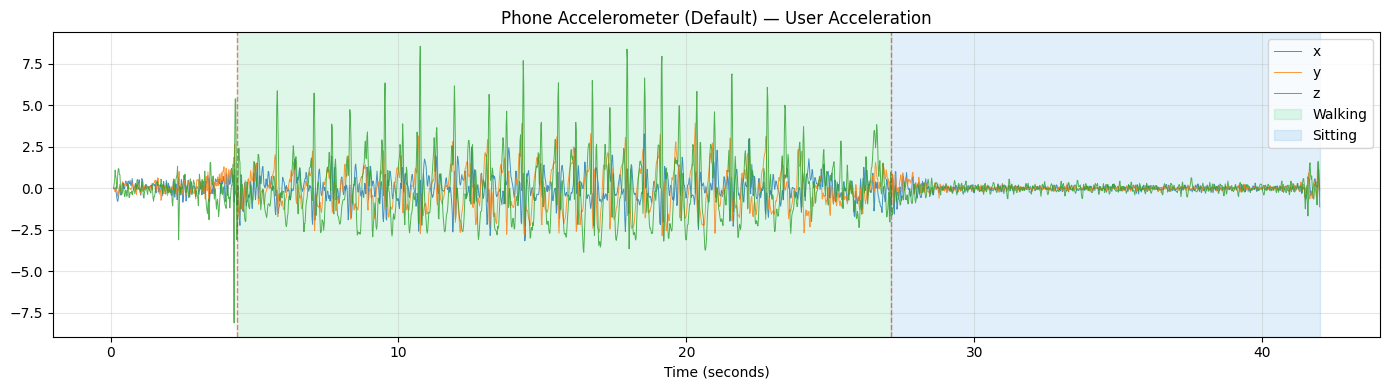

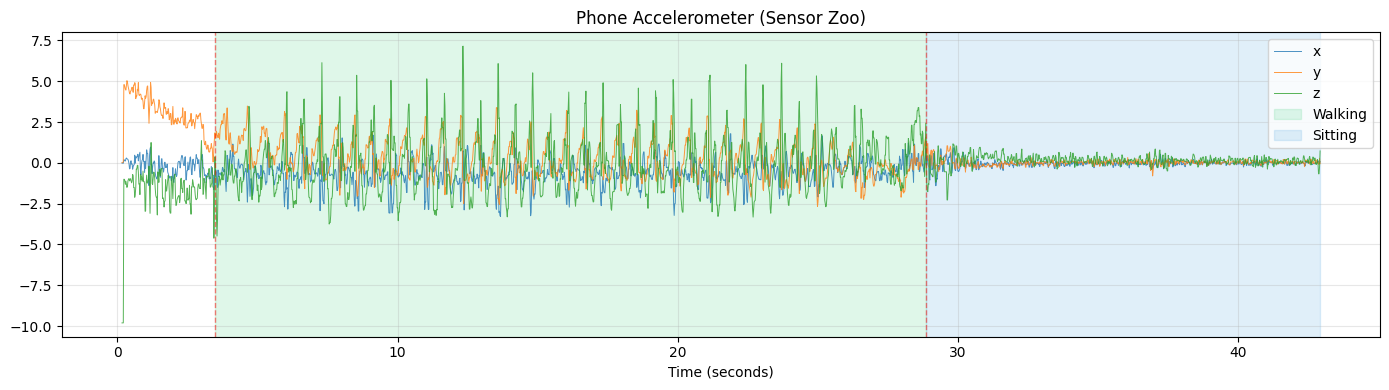

In [5]:
plot_xyz(default['Accelerometer.csv'], 'Phone Accelerometer (Default) — User Acceleration', ann_default)
plot_xyz(zoo['Accelerometer.csv'], 'Phone Accelerometer (Sensor Zoo)', ann_zoo)

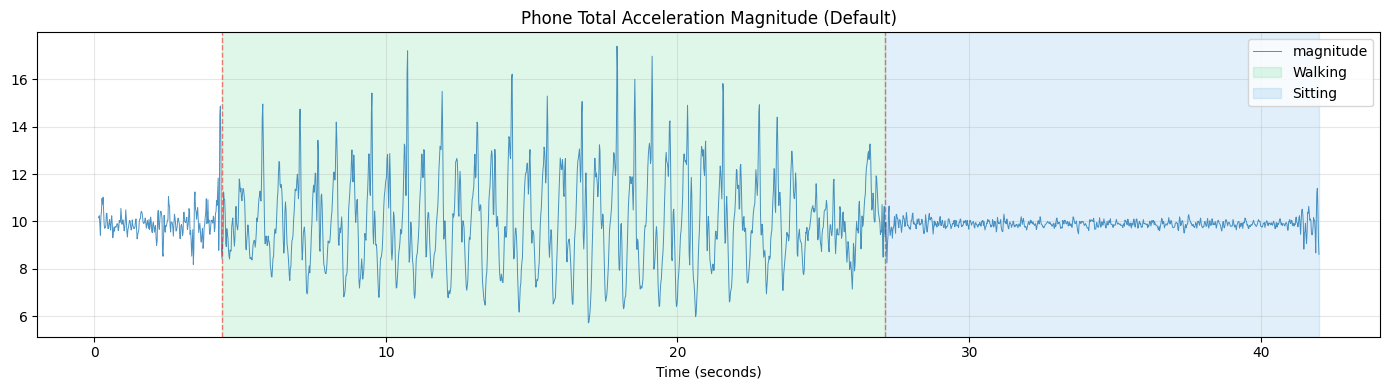

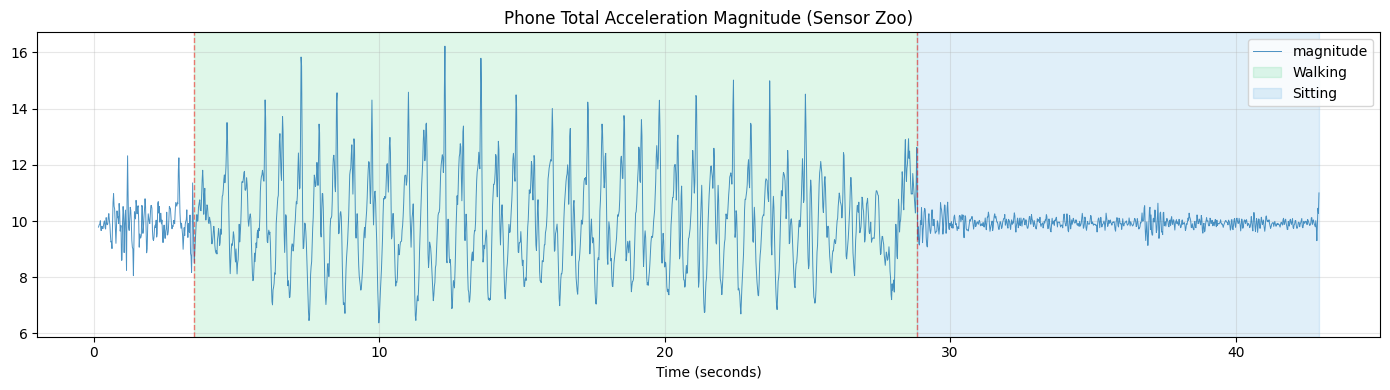

In [6]:
# Acceleration magnitude — easier to see walking vs sitting
for label, data, ann in [('Default', default, ann_default), ('Sensor Zoo', zoo, ann_zoo)]:
    df = data['TotalAcceleration.csv']
    if df is not None:
        df = df.copy()
        df['magnitude'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)
        plot_xyz(df, f'Phone Total Acceleration Magnitude ({label})', ann, cols=['magnitude'])

## 4. Phone Gyroscope

Rotation rate — walking produces periodic rotational patterns, sitting should be quiet.

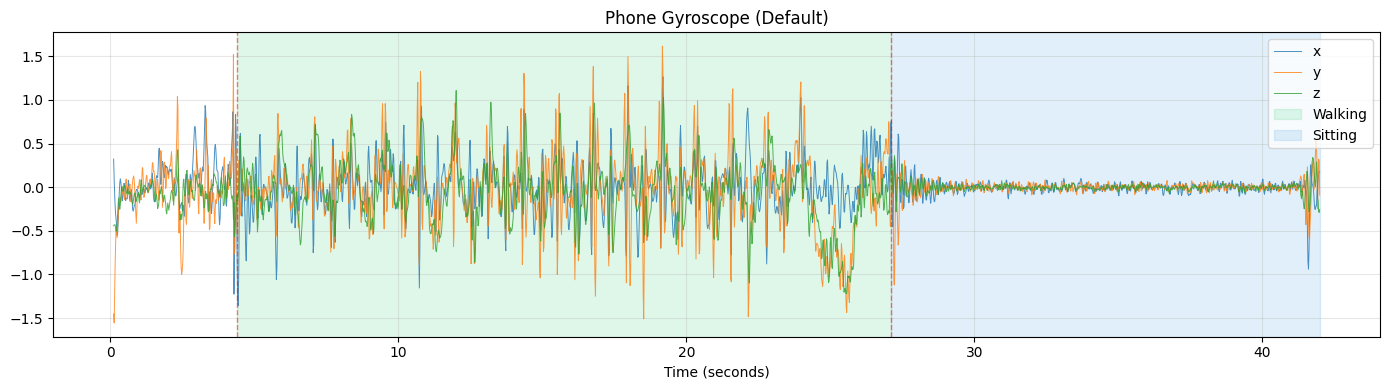

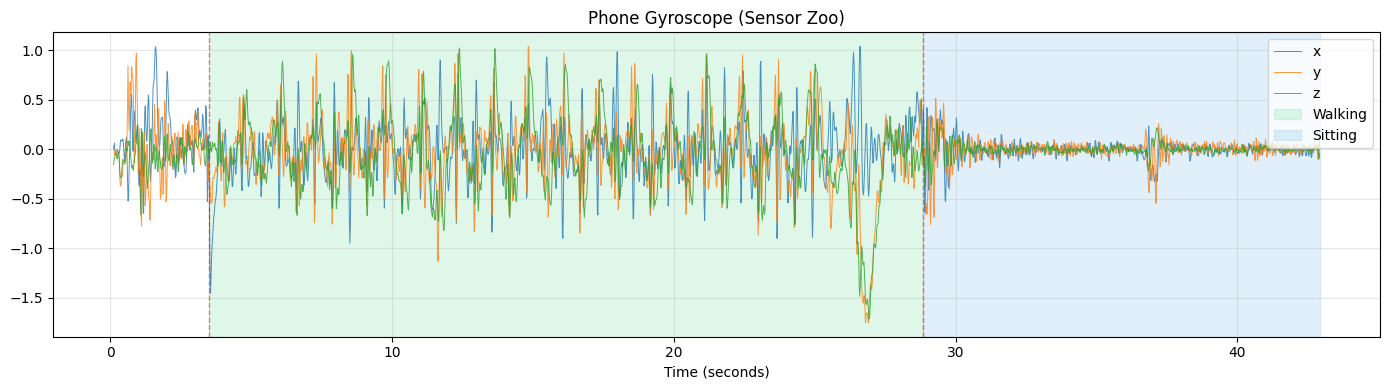

In [7]:
plot_xyz(default['Gyroscope.csv'], 'Phone Gyroscope (Default)', ann_default)
plot_xyz(zoo['Gyroscope.csv'], 'Phone Gyroscope (Sensor Zoo)', ann_zoo)

## 5. Orientation (Quaternion & Euler Angles)

This is where Default (Android OS fusion) vs Sensor Zoo (Madgwick) should differ most.
Compare roll, pitch, yaw between the two.

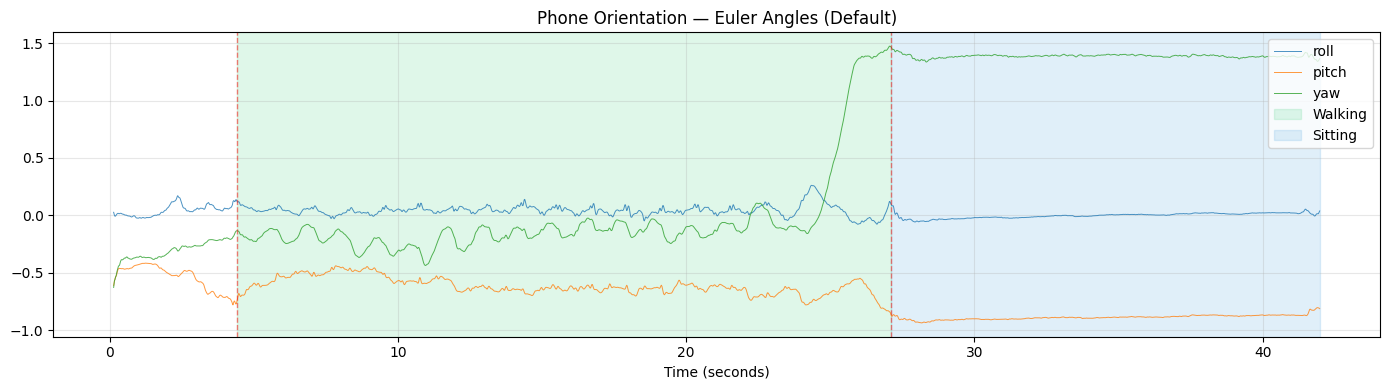

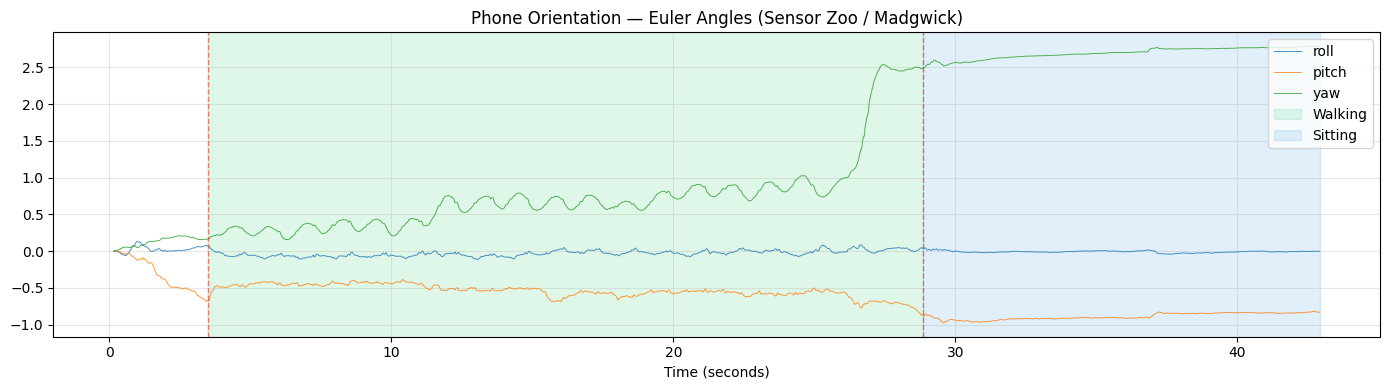

In [8]:
plot_xyz(default['Orientation.csv'], 'Phone Orientation — Euler Angles (Default)', ann_default, cols=['roll', 'pitch', 'yaw'])
plot_xyz(zoo['Orientation.csv'], 'Phone Orientation — Euler Angles (Sensor Zoo / Madgwick)', ann_zoo, cols=['roll', 'pitch', 'yaw'])

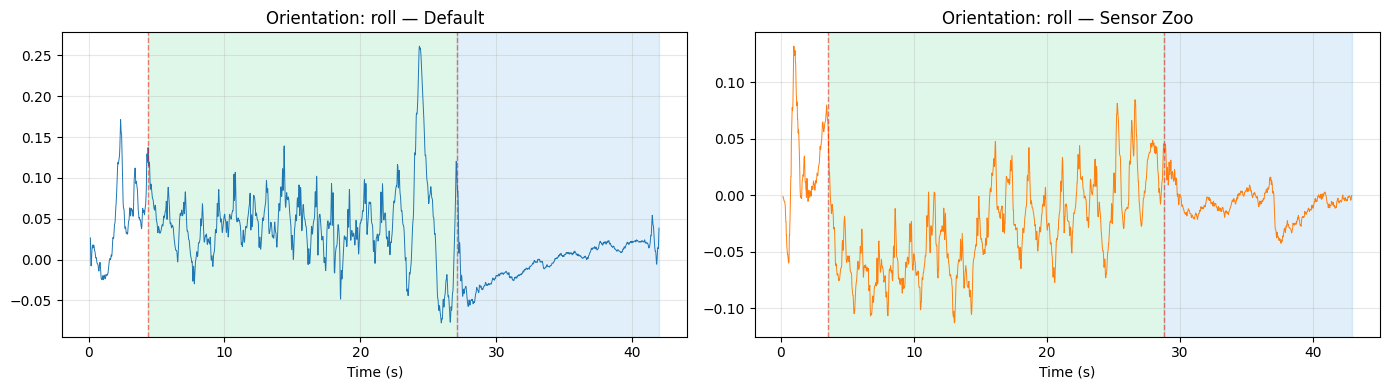

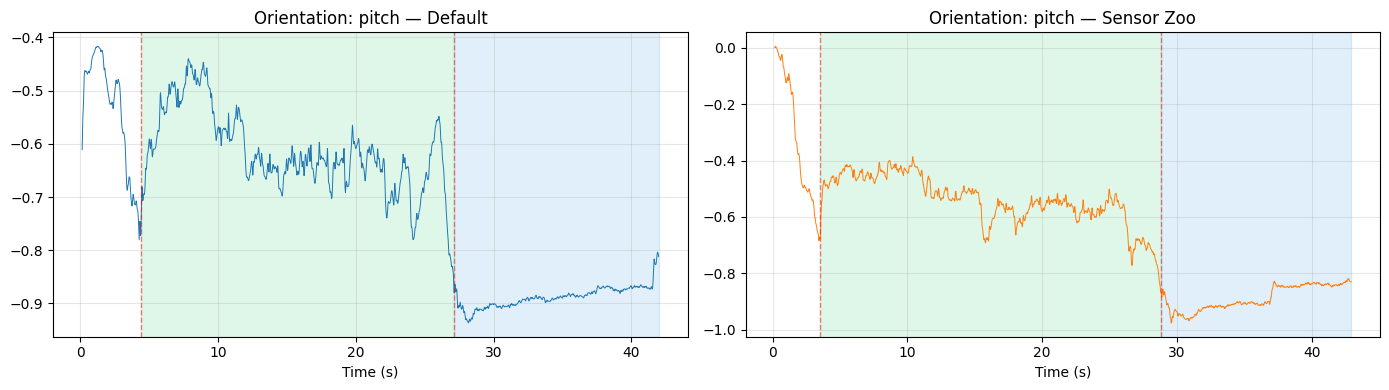

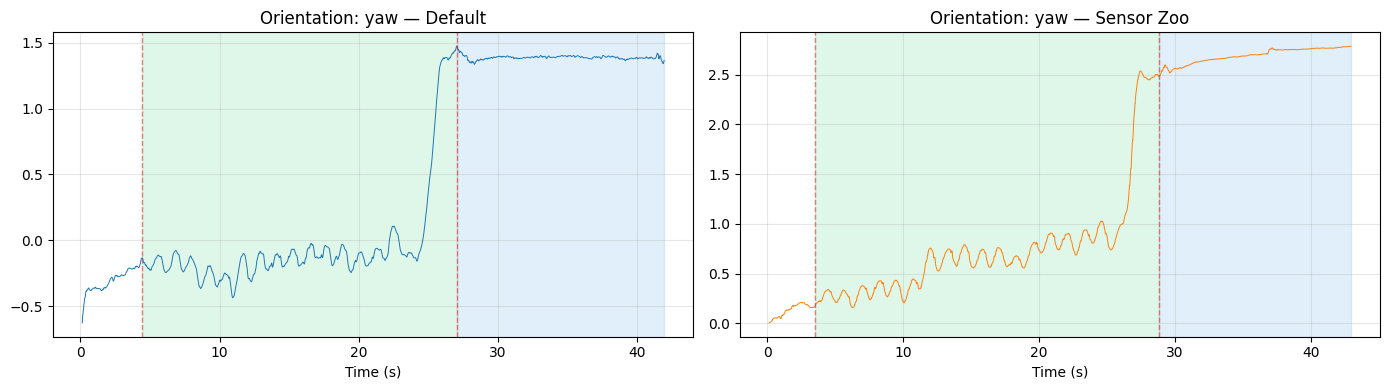

In [9]:
# Side-by-side for each angle
for angle in ['roll', 'pitch', 'yaw']:
    plot_comparison(default['Orientation.csv'], zoo['Orientation.csv'], angle,
                    f'Orientation: {angle}', ann_default, ann_zoo)

## 6. Barometer (Altitude)

Relative altitude changes — should be flat for walking on same floor, changes for stairs.
Compare phone barometer vs watch barometer.

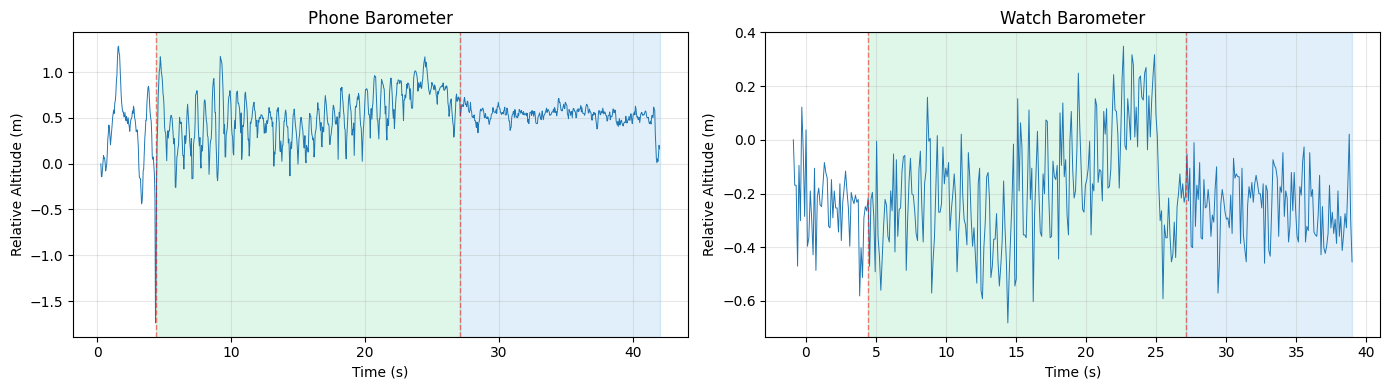

In [10]:
##### plot_xyz(default['Barometer.csv'], 'Phone Barometer (Default)', ann_default, cols=['relativeAltitude', 'pressure'])

# Phone vs Watch barometer
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for ax, key, title in [(ax1, 'Barometer.csv', 'Phone Barometer'), (ax2, 'WatchBarometer.csv', 'Watch Barometer')]:
    df = default[key]
    if df is not None:
        ax.plot(df['seconds_elapsed'], df['relativeAltitude'], linewidth=0.7)
        if ann_default:
            add_activity_shading(ax, ann_default, df['seconds_elapsed'].max())
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Relative Altitude (m)')
plt.tight_layout()
plt.show()

## 7. Compass / Heading

Magnetic bearing — should change when you turn, stay relatively stable when walking straight.

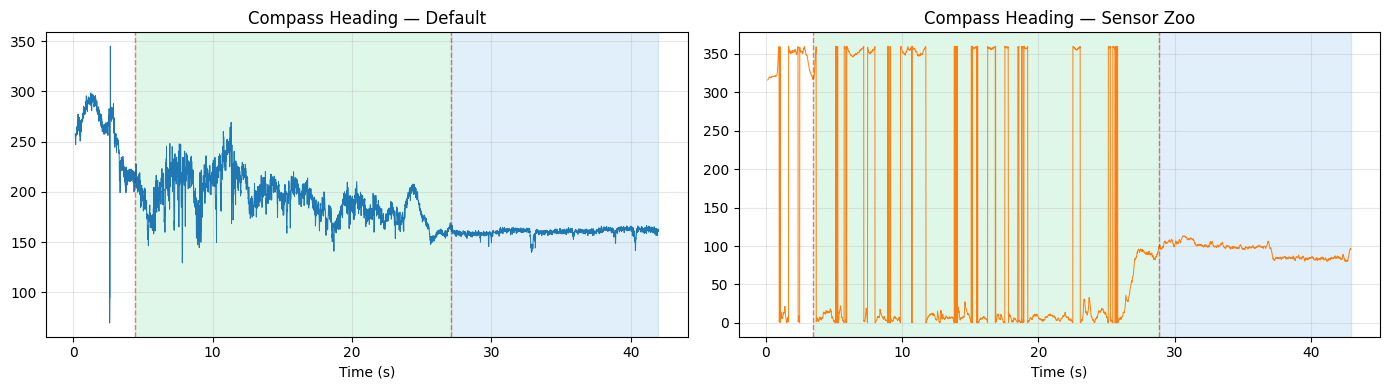

In [11]:
plot_comparison(default['Compass.csv'], zoo['Compass.csv'], 'magneticBearing',
                'Compass Heading', ann_default, ann_zoo)

## 8. Pedometer / Step Counter

Compare step counts between Default (Android built-in) and Sensor Zoo (Adaptive Threshold).

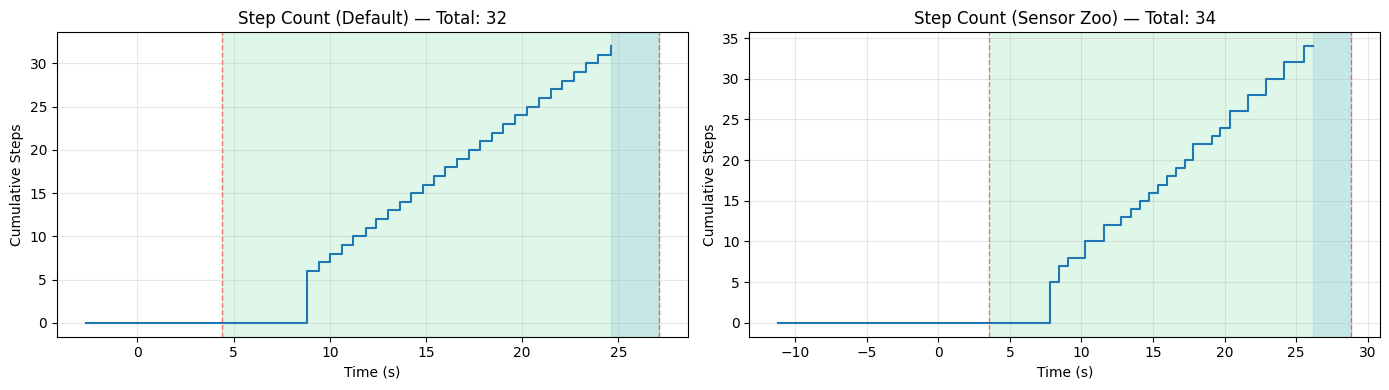

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, ann, label in [(ax1, default, ann_default, 'Default'), (ax2, zoo, ann_zoo, 'Sensor Zoo')]:
    df = data['Pedometer.csv']
    if df is not None:
        ax.step(df['seconds_elapsed'], df['steps'], where='post', linewidth=1.5)
        if ann:
            add_activity_shading(ax, ann, df['seconds_elapsed'].max())
        ax.set_title(f'Step Count ({label}) — Total: {df["steps"].max()}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Cumulative Steps')

plt.tight_layout()
plt.show()

## 9. Watch Sensors

Verify that watch data is synchronized and looks reasonable.

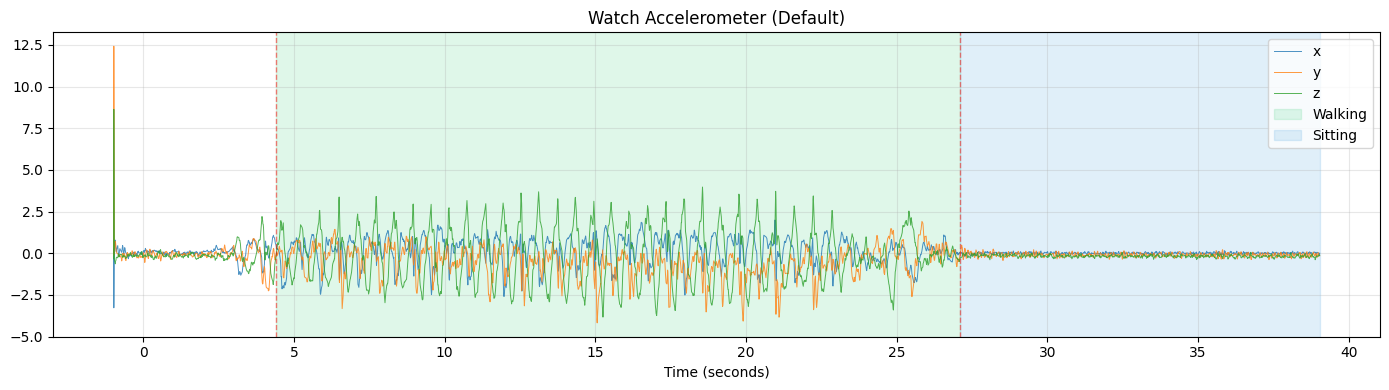

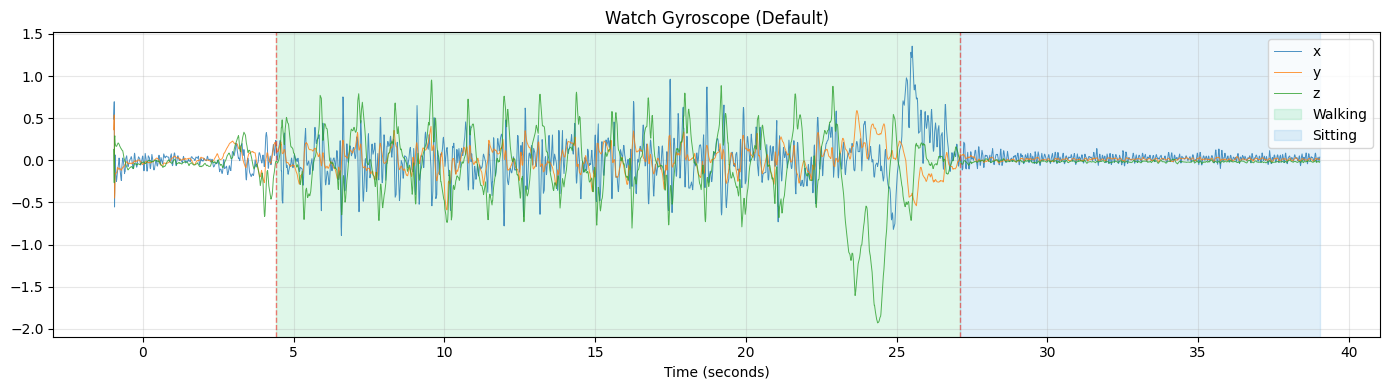

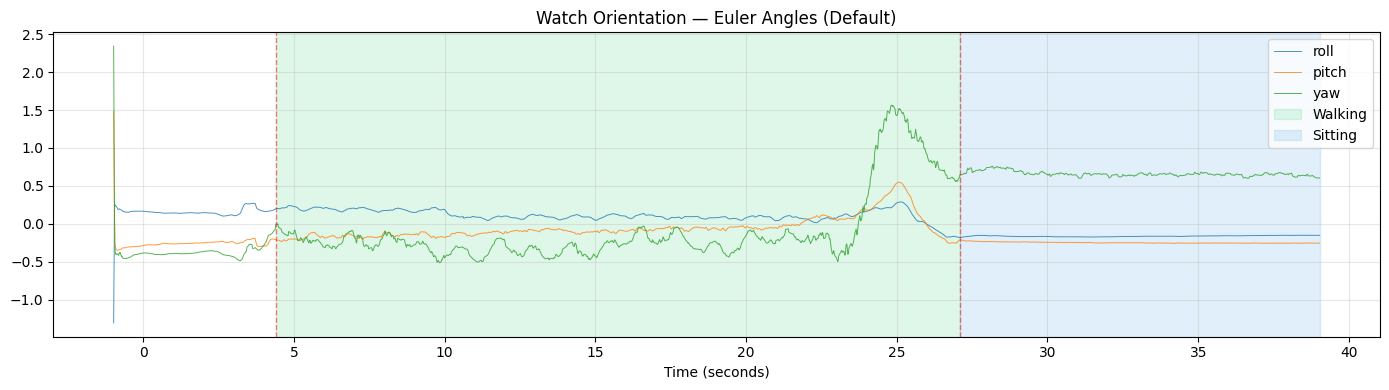

In [13]:
plot_xyz(default['WatchAccelerometer.csv'], 'Watch Accelerometer (Default)', ann_default)
plot_xyz(default['WatchGyroscope.csv'], 'Watch Gyroscope (Default)', ann_default)
plot_xyz(default['WatchOrientation.csv'], 'Watch Orientation — Euler Angles (Default)', ann_default, cols=['roll', 'pitch', 'yaw'])

## 10. Wi-Fi RSSI Scan

Check that all nearby APs are logged (not just the connected one).

In [14]:
wifi = default['WiFi.csv']
if wifi is not None:
    print(f'Total Wi-Fi scan entries: {len(wifi)}')
    print(f'Unique BSSIDs (access points): {wifi["BSSID"].nunique()}')
    print(f'Unique SSIDs (network names): {wifi["SSID"].nunique()}')
    print(f'Unique scan timestamps: {wifi["time"].nunique()}')
    print(f'\nAPs per scan (first scan):')
    first_scan_time = wifi['time'].iloc[0]
    first_scan = wifi[wifi['time'] == first_scan_time]
    print(f'  {len(first_scan)} APs detected')
    print(f'\nSample entries:')
    display(first_scan[['SSID', 'BSSID', 'level', 'frequency']].head(10))
else:
    print('No WiFi data found')

Total Wi-Fi scan entries: 62
Unique BSSIDs (access points): 56
Unique SSIDs (network names): 43
Unique scan timestamps: 2

APs per scan (first scan):
  23 APs detected

Sample entries:


,SSID,BSSID,level,frequency
0,TP-LINK_BF6B_5G,e8:de:27:b1:bf:6a,-85,5745
1,TP-Link_2D8E,5c:e9:31:ac:2d:8e,-63,2447
2,boordeel #2 (snel),50:91:e3:f9:41:a4,-85,5180
3,VUsec,30:de:4b:07:15:c9,-89,5240
4,TP-Link_A12A_5G,a8:42:a1:4e:a1:29,-64,5180
5,TP-LINK_21D5,30:b5:c2:67:21:d5,-84,2457
6,FRITZ!Box 7590 UQ,44:4e:6d:dd:e6:50,-55,2462
7,Jut&Julia,30:5a:3a:a4:cf:b8,-78,2472
8,TP-Link_0644,98:da:c4:20:06:44,-85,2462
9,Julia's huisje_EXT,cc:32:e5:8a:08:bc,-86,5500


## 11. Activity Detection (Sensor Logger built-in)

In [15]:
for label, data in [('Default', default), ('Sensor Zoo', zoo)]:
    act = data['Activity.csv']
    if act is not None and not act.empty:
        print(f'\n{label} — Activity Detection:')
        display(act)
    else:
        print(f'{label} — No activity data')


Default — Activity Detection:


,time,seconds_elapsed,activity
0,1774789948818000000,0.282,unknown
1,1774789953917000000,5.381,walking
2,1774789967208000000,18.672,walking
3,1774789971698000000,23.162,walking
4,1774789976775000000,28.239,walking



Sensor Zoo — Activity Detection:


,time,seconds_elapsed,activity
0,1774790030416000000,0.297,walking
1,1774790035510000000,5.391,walking
2,1774790044303000000,14.184,walking
3,1774790055413000000,25.294,walking


## 12. Sampling Rate Check

Verify actual sampling rates match expected 100Hz.

In [16]:
def check_sampling_rate(df, name):
    """Calculate actual sampling rate from timestamps."""
    if df is None or len(df) < 2:
        return None
    dt = df['seconds_elapsed'].diff().dropna()
    mean_dt = dt.mean()
    actual_hz = 1.0 / mean_dt if mean_dt > 0 else 0
    return {'sensor': name, 'mean_interval_ms': mean_dt*1000, 'actual_Hz': round(actual_hz, 1), 'samples': len(df)}

key_sensors = ['Accelerometer.csv', 'Gyroscope.csv', 'Orientation.csv', 'Magnetometer.csv',
               'WatchAccelerometer.csv', 'WatchGyroscope.csv', 'WatchOrientation.csv', 'WatchBarometer.csv',
               'WatchMagnetometer.csv','Barometer.csv', 'Compass.csv']

print('=== Default Recording ===')
rates_d = [check_sampling_rate(default[s], s.replace('.csv','')) for s in key_sensors]
display(pd.DataFrame([r for r in rates_d if r is not None]).set_index('sensor'))

print('\n=== Sensor Zoo Recording ===')
rates_z = [check_sampling_rate(zoo[s], s.replace('.csv','')) for s in key_sensors]
display(pd.DataFrame([r for r in rates_z if r is not None]).set_index('sensor'))

=== Default Recording ===


,mean_interval_ms,actual_Hz,samples
sensor,,,
Accelerometer,18.574517,53.8,2256
Gyroscope,18.595148,53.8,2253
Orientation,19.143863,52.2,2187
Magnetometer,10.045596,99.5,4168
WatchAccelerometer,13.741051,72.8,2913
WatchGyroscope,13.699966,73.0,2921
WatchOrientation,14.005579,71.4,2858
WatchBarometer,100.717178,9.9,397
WatchMagnetometer,14.162192,70.6,2825



=== Sensor Zoo Recording ===


,mean_interval_ms,actual_Hz,samples
sensor,,,
Accelerometer,18.594613,53.8,2300
Gyroscope,18.614757,53.7,2300
Orientation,19.079751,52.4,2243
Magnetometer,10.063500,99.4,4253
WatchAccelerometer,13.747054,72.7,3022
WatchGyroscope,13.745827,72.7,3023
WatchOrientation,14.169174,70.6,2932
WatchBarometer,100.630489,9.9,413
WatchMagnetometer,14.360252,69.6,2893


## 13. MobilePoser Compatibility Check

MobilePoser expects:
- Acceleration (3-axis) from phone and watch
- Orientation as rotation matrices (3x3) or quaternions from phone and watch
- Sampling rate: 60Hz (we'll downsample from 100Hz)

Let's verify we have what's needed.

In [17]:
print('=== MobilePoser Input Compatibility ===')
print()

# Check phone data
phone_accel = default['TotalAcceleration.csv']  # includes gravity, which MobilePoser expects
phone_orient = default['Orientation.csv']
print('Phone Acceleration:')
if phone_accel is not None:
    print(f'  Columns: {list(phone_accel.columns)}')
    print(f'  Has x,y,z: {all(c in phone_accel.columns for c in ["x","y","z"])}')
    print(f'  Rows: {len(phone_accel)}')

print('\nPhone Orientation:')
if phone_orient is not None:
    print(f'  Columns: {list(phone_orient.columns)}')
    print(f'  Has quaternion (qw,qx,qy,qz): {all(c in phone_orient.columns for c in ["qw","qx","qy","qz"])}')
    print(f'  Rows: {len(phone_orient)}')

# Check watch data
watch_accel = default['WatchAccelerometer.csv']
watch_orient = default['WatchOrientation.csv']
print('\nWatch Acceleration:')
if watch_accel is not None:
    print(f'  Columns: {list(watch_accel.columns)}')
    print(f'  Has x,y,z: {all(c in watch_accel.columns for c in ["x","y","z"])}')
    print(f'  Rows: {len(watch_accel)}')

print('\nWatch Orientation:')
if watch_orient is not None:
    print(f'  Columns: {list(watch_orient.columns)}')
    print(f'  Has quaternion (qw,qx,qy,qz): {all(c in watch_orient.columns for c in ["qw","qx","qy","qz"])}')
    print(f'  Rows: {len(watch_orient)}')

print('\n=== Notes ===')
print('- MobilePoser needs orientation as rotation matrices — convert quaternions to 3x3 matrices')
print('- MobilePoser expects 60Hz — downsample from 100Hz by interpolation')
print('- Phone and watch timestamps need to be aligned to a common timeline')
print('- Check MobilePoser source code for exact expected input tensor format')

=== MobilePoser Input Compatibility ===

Phone Acceleration:
  Columns: ['time', 'seconds_elapsed', 'z', 'y', 'x']
  Has x,y,z: True
  Rows: 2254

Phone Orientation:
  Columns: ['time', 'seconds_elapsed', 'qz', 'qy', 'qx', 'qw', 'roll', 'pitch', 'yaw']
  Has quaternion (qw,qx,qy,qz): True
  Rows: 2187

Watch Acceleration:
  Columns: ['time', 'seconds_elapsed', 'z', 'y', 'x']
  Has x,y,z: True
  Rows: 2913

Watch Orientation:
  Columns: ['time', 'seconds_elapsed', 'yaw', 'pitch', 'qy', 'qz', 'roll', 'qx', 'qw']
  Has quaternion (qw,qx,qy,qz): True
  Rows: 2858

=== Notes ===
- MobilePoser needs orientation as rotation matrices — convert quaternions to 3x3 matrices
- MobilePoser expects 60Hz — downsample from 100Hz by interpolation
- Phone and watch timestamps need to be aligned to a common timeline
- Check MobilePoser source code for exact expected input tensor format


# Step 0: Observations & Findings

## Recording Setup
- **App:** Sensor Logger v1.55.0 on Samsung SM-S911B (Android 36)
- **Watch:** WearOS smartwatch, synced via Phone & Watch mode
- **Activity:** ~25s walking, ~10s sitting, annotated manually
- **Two versions:** Default (Android OS fusion) and Sensor Zoo (Madgwick orientation, Adaptive Threshold steps, Tilt-Compensated compass)
- **Requested sampling rate:** 100Hz
- **Standardisation:** Enabled

---

## Key Findings

### 1. Actual Sampling Rates ≠ Requested

| Sensor | Requested | Actual (Phone) | Actual (Watch) |
|--------|-----------|----------------|----------------|
| Accelerometer/Gyroscope | 100 Hz | ~54 Hz | ~73 Hz |
| Orientation | 100 Hz | ~52 Hz | ~71 Hz |
| Magnetometer/Compass | 100 Hz | ~100 Hz | ~70 Hz |
| Barometer    | Max | 25 Hz | ~10 Hz |

**Implication:** The phone's IMU hardware caps at ~54Hz regardless of the requested rate. This is close to MobilePoser's required 60Hz, so we can interpolate up slightly rather than downsample. Watch samples faster (~73Hz) so phone is the bottleneck. All sensors need to be resampled to a common rate for synchronization.

### 2. Walking vs. Sitting is Clearly Distinguishable

In both recording versions:
- **Accelerometer:** Walking shows rhythmic spikes (step impacts), sitting is nearly flat
- **Gyroscope:** Walking shows periodic rotation patterns (body sway), sitting is quiet
- **Barometer:** Flat for same-floor walking (as expected — no altitude change in this test)

**Implication:** Activity recognition from raw sensor data should be achievable even with simple classifiers. The signal difference is visually obvious.

### 3. Default vs. Sensor Zoo: Different Noise Profiles

| Sensor | Default (Android OS) | Sensor Zoo (Madgwick) |
|--------|---------------------|----------------------|
| Accelerometer | Smoother (OS applies filtering) | Noisier (raw-er signal) |
| Gyroscope | Smoother | Noisier |
| Orientation | Noisier | Smoother (Madgwick fusion) |

**Explanation:** Android's built-in fusion applies proprietary smoothing to accelerometer and gyroscope outputs, making them appear cleaner but potentially hiding real dynamics. Madgwick doesn't filter the raw IMU signals — it only fuses accel+gyro+magnetometer for orientation estimation, where it produces a cleaner result.

**Implication for dead reckoning:** We could mix approaches — use default (smoother) accel/gyro for step detection, but Madgwick (smoother) orientation for heading. Or test both end-to-end and compare.

### 4. Column Order Differs Between Versions

| File | Default columns | Sensor Zoo columns |
|------|----------------|--------------------|
| Accelerometer | z, y, x | x, y, z |
| Orientation quaternion | qz, qy, qx, qw | qw, qx, qy, qz |

**Implication:** Preprocessing must handle column ordering explicitly by name, not position.

### 5. Built-in Activity Detection is Insufficient

Sensor Logger's Activity.csv only detected "walking" and "unknown" — it never detected "sitting." The detection is too coarse and infrequent (only 4-5 entries for a 35s recording) to be useful for our activity recognition task.

**Implication:** Manual annotations via presets are essential for ground truth. The built-in activity detection cannot replace them.

### 6. Wi-Fi Scans All Nearby Access Points ✓

- 56 unique BSSIDs detected across 2 scan intervals
- 23 APs per scan on average
- Includes SSID, BSSID, signal level (RSSI), and frequency
- Scans are infrequent (~2 per 40s recording)

**Implication:** Wi-Fi RSSI fingerprinting is possible with this setup for future work. However, scan frequency is low (~1 per 20s), so it can only provide occasional absolute position corrections, not continuous tracking.

### 7. MobilePoser Compatibility

| Requirement | Available? | Notes |
|-------------|-----------|-------|
| Phone acceleration (3-axis) | ✓ | TotalAcceleration.csv (includes gravity) |
| Phone orientation (quaternion) | ✓ | Orientation.csv — needs conversion to rotation matrix |
| Watch acceleration (3-axis) | ✓ | WatchAccelerometer.csv |
| Watch orientation (quaternion) | ✓ | WatchOrientation.csv — needs conversion to rotation matrix |
| 60 Hz sampling | ~ | Actual ~54Hz phone, ~73Hz watch — resample to 60Hz |
| Synchronized timestamps | ✓ | Same epoch time base |

**Conversion needed:**
1. Quaternion → 3×3 rotation matrix
2. Resample all sensors to common 60Hz timeline
3. Align phone and watch data to same timestamps
4. Verify coordinate system conventions match MobilePoser's expectations (check source code)

### 8. Pedometer Counts Differ

For similar-length recordings, Default and Sensor Zoo step counters gave different totals. This needs further investigation with a counted ground truth (actually count your steps next time).

---

## Data Summary

| Category | Phone Sensors | Watch Sensors |
|----------|--------------|---------------|
| Motion | Accelerometer, Gyroscope, Gravity, TotalAcceleration (+ uncalibrated variants) | Accelerometer, Gyroscope, Gravity, TotalAcceleration |
| Orientation | Orientation (quaternion + Euler), Magnetometer, Compass | Orientation (quaternion + Euler), Magnetometer |
| Environment | Barometer (25Hz), GPS/Location | Barometer, Location |
| Connectivity | Wi-Fi (all APs, ~1 scan/20s), Network | — |
| Activity | Pedometer, Activity (coarse), Annotations (manual) | — |

---

## Next Steps

- [ ] Record in the NU building with annotation presets for walking, stairs, sitting, standing
- [ ] Count actual steps during recording for pedometer ground truth
- [x] Check MobilePoser source code for exact input format and coordinate conventions
- [ ] Implement EKF / PDR on the raw `acc` / `ori` signals as the classical baseline
- [ ] Compare trajectory drift: classical PDR vs MobilePoser's `tran_pred`